![Firefighters battle house fires along the Pacific Coast Highway in Malibu, January 2025 (Wally Skalij / Los Angeles Times)](firetruck.jpeg)

# **About**

**Background & Purpose** 

The 2025 Palisades and Eaton wildfires were highly destructive fires in the Los Angeles County. The fires claimed a combined total of over 30 lives, 34,000 acres of land, and 16,000 buildings. This analysis contains two tasks related to the fires: 1. Practice working with `xarray` data and creating images from remote sensing data, 2. Practice working with census data and visualizing Environmental Justice Index (EJI) variables within the wildfire's extent.

**GitHub Links**

[Task 1: EDS 220 - Homework 4](https://github.com/zachyyy700/eds220-hwk4)

[Task 2: EDS 220 - Week 8 Discussion](https://github.com/zachyyy700/eds220-2025-discussions/blob/main/section-8-fires.ipynb)

**Highlights**

| Task 1 | Task 2 |
| -------- | ------- |
| - Explore `xarray` data format | - Polygon intersections |
| - Handle extreme values in remote sensing data | - Polygon clipping |
| - Plot true color images | - Adding basemaps |
| - Plot false color images | - Visualize socio-economic distributions of EJI variables |


**Data**

- Fire perimeter data: Sourced from CAL FIRE hosted by California's Open Data Portal. This dataset contains information and geometries for wildfires in California.
- Landsat data: Sourced from the Landsat Collection 2 Level-2 atmosperically corrected surface reflectance data, courtesy of the Landsat 8 satelliite.
- EJI data: Sourced from the Centers for Disease Control's (CDC) Geospatial Research, Analysis, and Services Program (GRASP). These data are contained within a GeoPackage and contains measurements on numerous socioeconomic and health variables.

**References**

CAL FIRE / California Department of Forestry and Fire Protection. (2025). California Fire Perimeters (all) [dataset]. State of California. Accessed November 16, 2025, from [https://data.ca.gov/dataset/california-fire-perimeters-all]()

Earth Resources Observation and Science (EROS) Center. (2025). Landsat 8-9 Operational Land Imager / Thermal Infrared Sensor Level-2, Collection 2 [dataset]. U.S. Geological Survey. [https://doi.org/10.5066/P9OGBGM6](). Accessed November 16, 2025, via Microsoft Planetary Computer: [https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2]().

Centers for Disease Control and Prevention and Agency for Toxic Substances Disease Registry. 2024 Environmental Justice Index. Accessed November 20, 2025. [https://atsdr.cdc.gov/place-health/php/eji/eji-data-download.html]()

# Task 1 Analysis

## Load packages and data

In [82]:
# Load packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr
import rioxarray as rioxr
from janitor import clean_names
import contextily as ctx
from matplotlib.lines import Line2D

In [83]:
# Load data
fp1 = os.path.join("data", "California_Historic_Fire_Perimeters_-5643920427189821347.geojson")
perimeter_data = gpd.read_file(fp1).clean_names()

fp2 = os.path.join("data", "landsat8-2025-02-23-palisades-eaton.nc")
landsat_data = xr.open_dataset(fp2)

## Fire Perimeter Data Exploration

In [84]:
print(f"Decades Value Counts:\n{perimeter_data['decades'].value_counts()}\n")
print(f"Coordinates Reference System (CRS): {perimeter_data.crs}\n")
print(f"Is this CRS projected?: {perimeter_data.crs.is_projected}")

Decades Value Counts:
decades
1950-1959            7012
2010-2019            3425
2000-2009            2905
1980-1989            2208
2020-January 2025    2036
1990-1999            1992
1970-1979            1879
1960-1969            1276
Name: count, dtype: int64

Coordinates Reference System (CRS): EPSG:3857

Is this CRS projected?: True


**Fire perimeter description**: The fire perimeter data was downloaded from CAL FIRE hosted by California's Open Data Portal. Some preliminary findings about the data included the unique observation counts of the decade variable. This shows how many observations of wildfires there are for each decade group in the data. Next, the CRS was shown to be EPSG:3857 and it is also a projected CRS.

### Fire Perimeters Initial Plot

<Axes: >

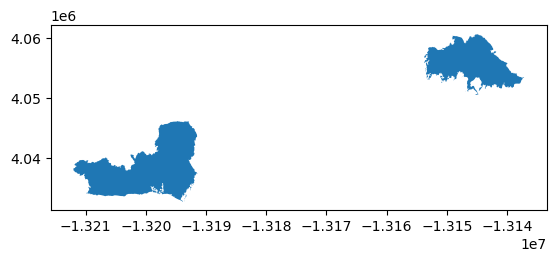

In [110]:
# Filter perimeter data to fires of interest
palisades_eaton = perimeter_data[(perimeter_data['fire_name'].isin(['PALISADES', 'EATON'])) & 
                                  (perimeter_data['year_'] == 2025)]

# Initial plot
palisades_eaton.plot()

## Landsat Data Exploration

In [87]:
print(f"{landsat_data.data_vars}\n")
print(f"{landsat_data.coords}\n")
print(f"Time Value: {landsat_data.time.values}\n")
print(f"Dimensions: {landsat_data.dims}")

Data variables:
    red          (y, x) float32 16MB ...
    green        (y, x) float32 16MB ...
    blue         (y, x) float32 16MB ...
    nir08        (y, x) float32 16MB ...
    swir22       (y, x) float32 16MB ...
    spatial_ref  int64 8B ...

Coordinates:
  * y        (y) float64 11kB 3.799e+06 3.799e+06 ... 3.757e+06 3.757e+06
  * x        (x) float64 22kB 3.344e+05 3.344e+05 ... 4.166e+05 4.166e+05
    time     datetime64[ns] 8B ...

Time Value: 2025-02-23T18:28:13.651369000

Dimensions: FrozenMappingWarningOnValuesAccess({'y': 1418, 'x': 2742})


**Landsat description**: Preliminary exploration of the landsat data yielded information on the data's dimensions, coordinates, and variables. This is an xarray Dataset, thus it contains 2D numpy arrays for each variable present in the data. These variables are each a spectral band collected by the Landsat 8 satellite. The coordinates of the variables are also included in the data and these are geospatial x and y coordinates. Given that they're in scientific notation like "3.799e+06", these coordinates are likely in meters. Additionally, there is a time coordinate but there is only one value since this data is only from one point in time. This time value was extracted and the data is from February 23, 2025. Last, the dimensions of the variables were found and they have a length of 2742 in the x coordinate and 1418 in the y coordinate.

## Restoring Geospatial Info

In [88]:
# Print dataset crs
print(f"Current CRS: {landsat_data.rio.crs}")

Current CRS: None


Currently, the geospatial information like Coordinate Reference System (CRS) isn't loaded correctly into the data, indicated by "None" output in the above cell. However, this CRS information is stored within the data variable `spatial_ref` and can be accessed.

In [89]:
# Print spatial ref variable crs
print(landsat_data.spatial_ref.crs_wkt)

PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]


Now the `.spatial_ref.crs_wkt` can be applied with `.rio.write_crs()` and the DataSet's geospatial information will be loaded correctly and it's ready to be mapped.

In [111]:
# Set dataset CRS
landsat_data = landsat_data.rio.write_crs(landsat_data.spatial_ref.crs_wkt)

# Print newly assigned crs
print(f"Current CRS: {landsat_data.rio.crs}")

Current CRS: EPSG:32611


## True Color Image

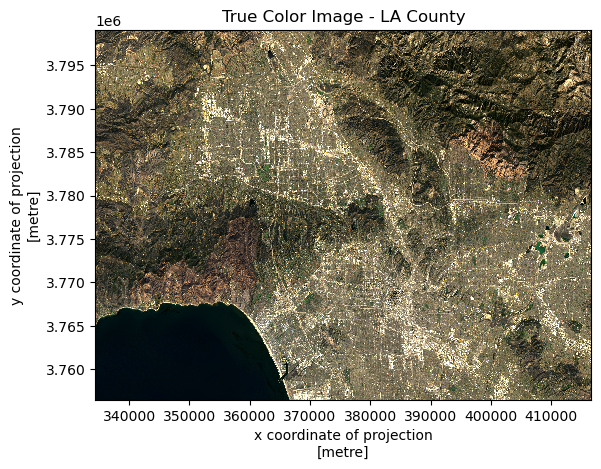

In [117]:
fig, ax = plt.subplots()

# Fill nans with 0 & plot
landsat_data[['red', 'green', 'blue']].fillna(value=0).to_array().plot.imshow(robust=True)

plt.title("True Color Image - LA County")
plt.show()

Initially trying to plot the true color image came with two issues. One, extreme values (mainly from clouds) in the landsat data were affecting the color plotting. To fix this, setting the `robust=True` made `xarray` ignore the top and bottom 2% extreme color values and the true color image could be seen. Next, invalid values were also present in the data. These were `np.nan`values and `xarray` doesn't know what to do with these. Instead, we replace these with zero with `.fillna()` and we end up with a final true color plot with no warnings.

## False Color Image

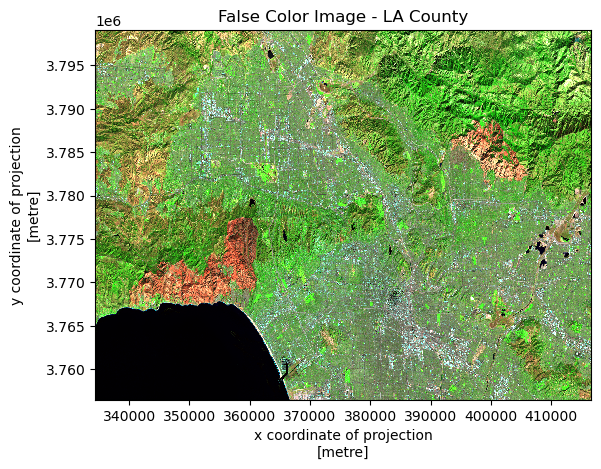

In [119]:
fig, ax = plt.subplots()

# Input different bands into rgb channels for false color image
landsat_data[['swir22', 'nir08', 'red']].fillna(value=0).to_array().plot.imshow(robust=True)

plt.title("False Color Image - LA County")
plt.show()

The same techniques with the `robust` parameter and the `.fillna()` method were applied to obtain a false color image. Instead of assigning the red, green, and blue bands to the red, green, and blue channels, a different band combination (SWIR, NIR, red) was assigned to the RGB channels. This created an image where areas affected by the fires stand out much more.

## Combined Map

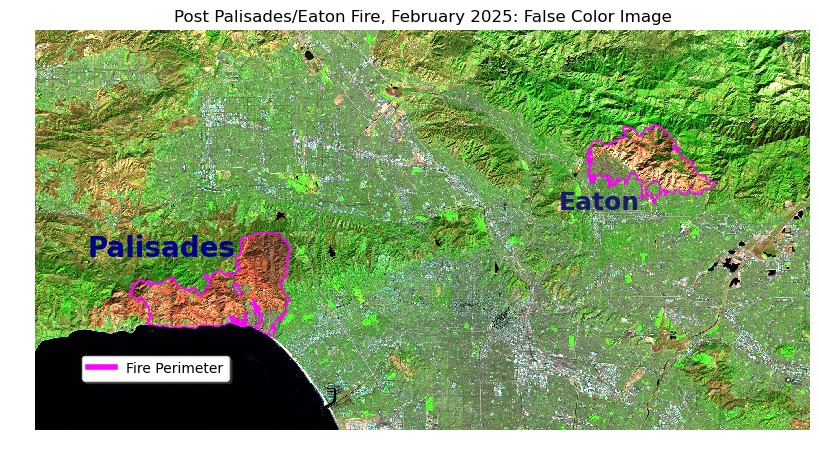

In [ ]:
# Set crs of fire perimeter data to match landsat data
palisades_eaton = palisades_eaton.to_crs("EPSG:32611")

# Initialize figure
fig, ax = plt.subplots(figsize=(10,8))

# Turn off axes
ax.axis('off')

# Plot landsat false color
landsat_data[['swir22', 'nir08', 'red']].fillna(value=0).to_array().plot.imshow(ax=ax, robust=True)
# Plot fire perimeters on top of false color image
palisades_eaton.plot(ax=ax, facecolor='None', edgecolor='fuchsia')

# Add fire text
ax.text(x=340000, y=3775000, s="Palisades", fontsize=20, color='darkblue', weight='bold')
ax.text(x=390000, y=3780000, s="Eaton", fontsize=18, color='midnightblue', weight='bold')

# Custom legend
custom_line = [Line2D([0], [0], color='fuchsia', lw=4)]
fig.legend(custom_line, ['Fire Perimeter'],  loc=(0.1, 0.2), fontsize=10, shadow=True)

plt.title("Post Palisades/Eaton Fire, February 2025: False Color Image")
plt.show()

Again, short-wave infrared (SWIR) was assigned to the red channel, near-infrared (NIR) to the green, and red to the blue channel. This combination was used to see the effects after the January 2025 Palisades-Eaton fires. Areas affected by the fires standout as a bright orange, almost red color. Additionally, the actual perimeter of the fires are outlined in pink.

# Task 2 Analysis

## Load EJI Data

In [99]:
# Load data from gdb file
fp3 = os.path.join("data", "EJI_2024_California", "EJI_2024_California.gdb")
eji_data = gpd.read_file(fp3).clean_names()

## Polygon Intersection

Before plotting the fire perimeter boundaries on top of the census data. The CRSs of the two datasets must match.

In [100]:
# Change EJI CRS before joining
if perimeter_data.crs != eji_data.crs:
    print(f"No CRS match. Matching now to {perimeter_data.crs} ")
    eji_data = eji_data.to_crs(perimeter_data.crs)
else:
    print("CRS match.")

No CRS match. Matching now to EPSG:3857 


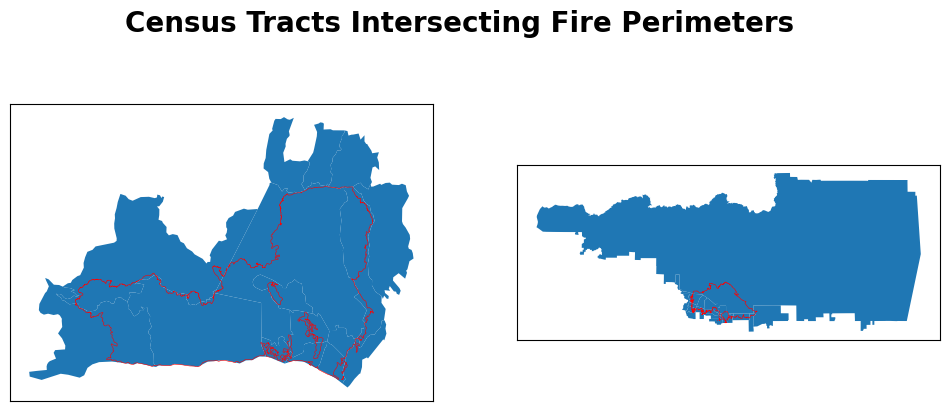

In [101]:
# Filter to 2025 Palisades
palisades_perimeter = perimeter_data[(perimeter_data['fire_name'] == "PALISADES") & (perimeter_data['year_'] == 2025)]
palisades_census = gpd.sjoin(left_df=eji_data, right_df=palisades_perimeter, how='inner')
# Filter to 2025 Eaton
eaton_perimeter = perimeter_data[(perimeter_data['fire_name'] == "EATON") & (perimeter_data['year_'] == 2025)]
eaton_census = gpd.sjoin(left_df=eji_data, right_df=eaton_perimeter, how='inner')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

for ax in (ax1, ax2):
    ax.set_xticks([])
    ax.set_yticks([])

palisades_census.plot(ax=ax1)
palisades_perimeter.boundary.plot(ax=ax1, edgecolor='red', linewidth=0.4)

eaton_census.plot(ax=ax2)
eaton_perimeter.boundary.plot(ax=ax2, edgecolor='red', linewidth=0.4)

fig.suptitle("Census Tracts Intersecting Fire Perimeters", size = 20, weight = "bold")

plt.show()

## Polygon Clipping

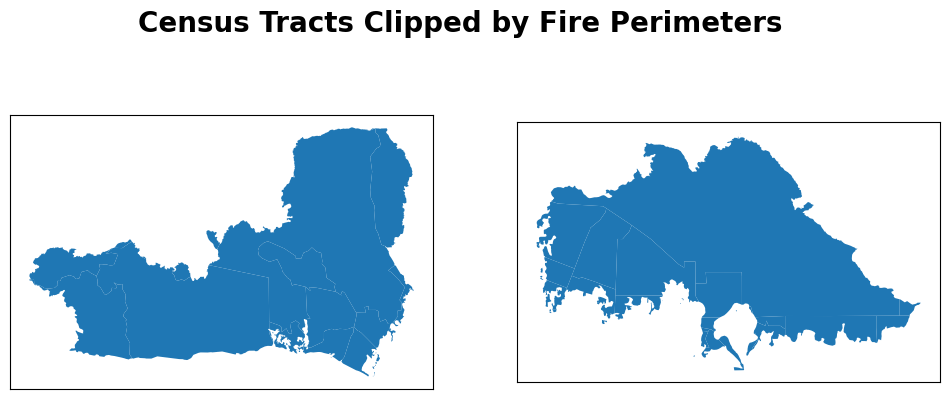

In [102]:
palisades_clip = gpd.clip(gdf=palisades_census, mask=palisades_perimeter)
eaton_clip = gpd.clip(gdf=eaton_census, mask=eaton_perimeter)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

for ax in (ax1, ax2):
    ax.set_xticks([])
    ax.set_yticks([])

palisades_clip.plot(ax=ax1)
eaton_clip.plot(ax=ax2)

fig.suptitle("Census Tracts Clipped by Fire Perimeters", size=20, weight='bold')

plt.show()

## Visualize with Basemap

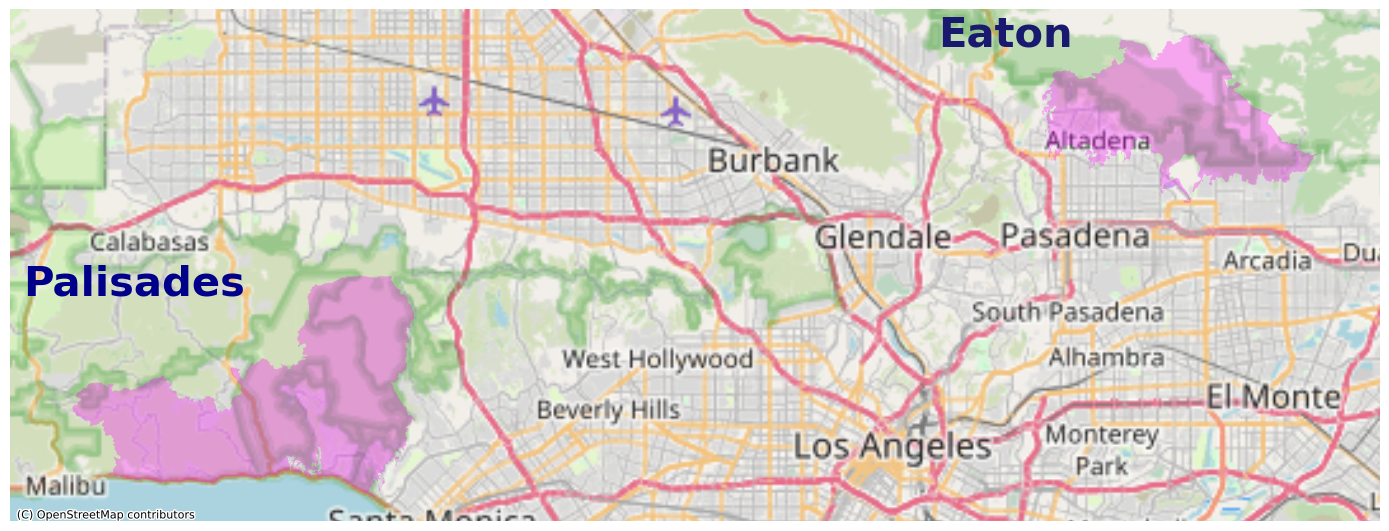

In [103]:
fig, ax = plt.subplots(figsize=(14, 12))


# ADD FIRE PERIMETERS: UPDATE FILL TRANSPARENCY AND COLOR
palisades_clip.plot(ax=ax, facecolor='fuchsia', alpha=0.3)
eaton_clip.plot(ax=ax, facecolor='fuchsia', alpha=0.3)

# Add basemap using contextily
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# ADD LEGEND OR ANNOTATION TO IDENTIFY EACH FIRE
ax.text(x=-13215000, y=4045000, s="Palisades", fontsize=30, color='darkblue', weight='bold')
ax.text(x=-13160000, y=4060000, s="Eaton", fontsize=30, color='midnightblue', weight='bold')
# ADD TITLE

ax.axis('off')

plt.tight_layout()
plt.show()

With the addition of the basemap, the fire perimeters (in pink) are placed within a larger geographical context and the surrounding LA County area can be seen.

## Visualize with EJI Data

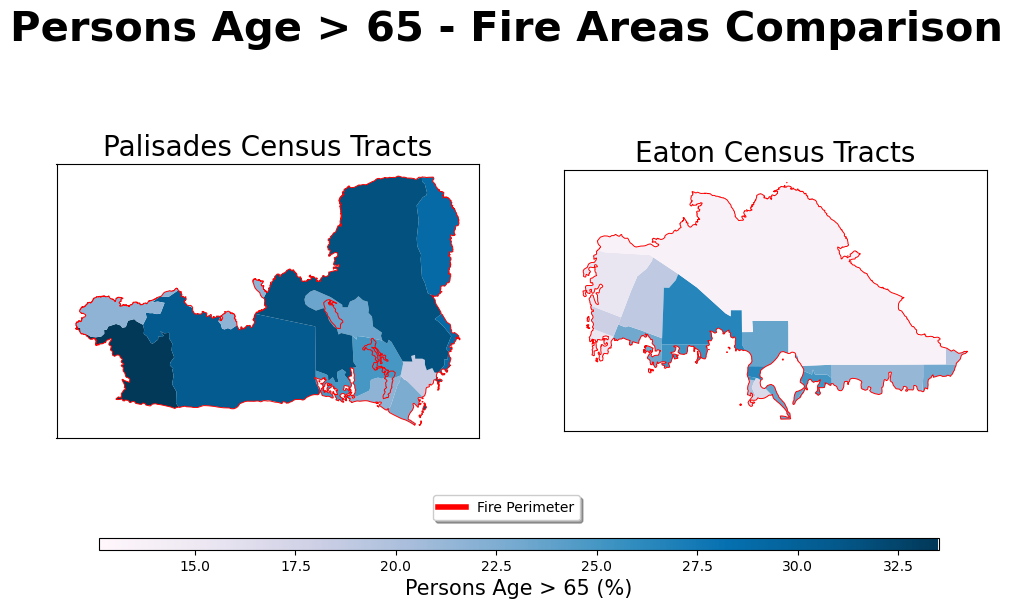

In [123]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

for ax in (ax1, ax2):
    ax.set_xticks([])
    ax.set_yticks([])

# Set EJI variable
eji_variable = 'e_age65'

# Find common min/max for legend range
vmin = min(palisades_census[eji_variable].min(), eaton_census[eji_variable].min())
vmax = max(palisades_census[eji_variable].max(), eaton_census[eji_variable].max())

# Plot census tracts within Palisades perimeter
#palisades_census.boundary.plot(ax=ax1, edgecolor='gray')
palisades_clip.plot(column= eji_variable, vmin=vmin, vmax=vmax, legend=False, ax=ax1, cmap='PuBu')
palisades_perimeter.boundary.plot(ax=ax1, edgecolor='red', linewidth=0.7)

ax1.set_title('Palisades Census Tracts', size=20)

# Plot census tracts within Eaton perimeter
#eaton_census.boundary.plot(ax=ax2, edgecolor='gray')
eaton_clip.plot(column=eji_variable, vmin=vmin, vmax=vmax, legend=False, ax=ax2, cmap='PuBu')
eaton_perimeter.boundary.plot(ax=ax2, edgecolor='red', linewidth=0.7)

ax2.set_title('Eaton Census Tracts', size=20)

# Add overall title
fig.suptitle('Persons Age > 65 - Fire Areas Comparison', size=30, weight='bold')

# Custom legend
custom_line = [Line2D([0], [0], color='red', lw=4)]
fig.legend(custom_line, ['Fire Perimeter'], bbox_to_anchor=(0.5, 0.15), loc='center', fontsize=10, shadow=True)

# Add shared colorbar at the bottom
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap='PuBu')
cbar_ax = fig.add_axes([0.16, 0.08, 0.7, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Persons Age > 65 (%)', size=15)

plt.show()

The final plot shows the California census tracts but only clipped to their respective fire perimeter. Additionally, the census tracts are colored by the `e_age65` variable, which is an estimate of the percentage of population over the age 65 in that tract. With this variable, we can see the geographic distribution of percent elderly populations of each census tract.